In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tensorflow.keras import layers, models
from utils import Load_img

In [10]:
# 2. Константы и пути
INPUT_SHAPE = (64, 64, 3)
BATCH_SIZE = 32
EPOCHS = 80
TRAIN_FOLDER = './data/bottle/train/good'
TEST_FOLDER = './data/bottle/test/good'
MODEL_SAVE_PATH = "./AE.keras"
PLOT_SAVE_PATH = "./loss_plot.png"

In [11]:

def build_cae(input_shape=(64, 64, 3)):
    inputs = layers.Input(shape=input_shape)
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2)(inputs) # 64->32
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)(x)      # 32->16
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', strides=2)(x)     # 16->8
    x = layers.BatchNormalization()(x)

    bottleneck = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x) # 8x8x256

    # Decoder
    x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same', strides=2)(bottleneck) # 8->16
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x)      # 16->32
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(x)      # 32->64
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # 64x64x3

    model = models.Model(inputs, outputs, name="CAE_Anomaly_Detector")
    return model


In [12]:
img_train = Load_img(TRAIN_FOLDER)
img_test = Load_img(TEST_FOLDER)

cae_model = build_cae(input_shape=INPUT_SHAPE)
cae_model.compile(optimizer='adam', loss='mse')
cae_model.summary()

Model: "CAE_Anomaly_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 778,371 (2.97 MB)

 Trainable params: 777,475 (2.97 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history = cae_model.fit(
    img_train, img_train,
    validation_data=(img_test, img_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - loss: 0.0903 - val_loss: 0.1274
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0154 - val_loss: 0.1234
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0101 - val_loss: 0.1214
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0075 - val_loss: 0.1213
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0062 - val_loss: 0.1205
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.0053 - val_loss: 0.1198
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0046 - val_loss: 0.1196
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 0.0041 - val_loss: 0.1187
Epoch 9/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - loss: 0.0036 - val_loss: 0.1182
Epoch 10/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 0.0032 - val_loss: 0.1172
Epoch 11/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - loss: 0.0029 - val_loss: 0.1157
Epoch 12/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 0.0026 - val_lo

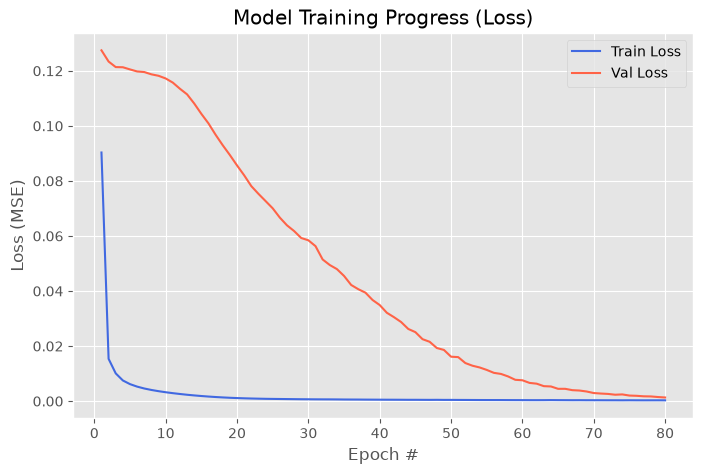

In [ ]:
plt.style.use("ggplot")
plt.figure(figsize=(8, 5))
epochs_range = np.arange(1, EPOCHS + 1)
plt.plot(epochs_range, history.history["loss"], label="Train Loss", color="royalblue")
plt.plot(epochs_range, history.history["val_loss"], label="Val Loss", color="tomato")
plt.title("Model Training Progress (Loss)")
plt.xlabel("Epoch #")
plt.ylabel("Loss (MSE)")
plt.legend()

In [15]:
plt.savefig(PLOT_SAVE_PATH)
cae_model.save(MODEL_SAVE_PATH)

<Figure size 640x480 with 0 Axes>